# Week 3 — Baseline Model Implementation
## Heart Disease Classification (UCI Cleveland)

**MSAI 699 Capstone Project — Rajesh Sahoo, University of the Cumberlands**

**Objective.** Establish a reproducible baseline classifier that predicts the
presence of heart disease from clinical measurements, record initial
performance metrics, and identify areas for improvement. This notebook
implements the standard machine-learning baseline workflow (clean → split →
pipeline → fit → evaluate → interpret → tune) that the capstone will reuse when
benchmarking its project-specific models.

**Dataset.** Processed Cleveland database from the UCI Heart Disease
repository (Detrano et al., 1989): 303 patient records, 13 clinical features,
and an integer target `num` (0 = no disease; 1–4 = disease present). Following
standard practice, the target is binarized to presence (1) vs. absence (0).

In [1]:
# 1. Setup and reproducibility
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay,
                             classification_report)

RANDOM_STATE = 42          # fixed seed for reproducibility
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

print("numpy", np.__version__, "| pandas", pd.__version__,
      "| scikit-learn", sklearn.__version__)

numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1


## 2. Load the data

The processed file has no header row; column names come from the dataset
documentation (`heart-disease.names`). Missing values are encoded as `?`.

In [2]:
import os

# Portable data loading: use the local file if present (running inside the
# capstone folder), otherwise download from the UCI repository. This lets the
# notebook run unchanged on Hugging Face, Colab, or Kaggle.
LOCAL_PATH = "../heart disease(1)/processed.cleveland.data"
UCI_URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
           "heart-disease/processed.cleveland.data")
DATA_PATH = LOCAL_PATH if os.path.exists(LOCAL_PATH) else UCI_URL
print("Loading from:", "local file" if DATA_PATH == LOCAL_PATH else "UCI URL")

columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
           "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]
df = pd.read_csv(DATA_PATH, header=None, names=columns, na_values="?")
print("Shape:", df.shape)
df.head()

Loading from: local file
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### Feature reference

| Feature | Meaning |
|---|---|
| age | Age in years |
| sex | 1 = male, 0 = female |
| cp | Chest-pain type (1–4) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl (1/0) |
| restecg | Resting ECG result (0–2) |
| thalach | Max heart rate achieved |
| exang | Exercise-induced angina (1/0) |
| oldpeak | ST depression (exercise vs. rest) |
| slope | Slope of peak exercise ST segment |
| ca | Number of major vessels (0–3) |
| thal | Thalassemia (3, 6, 7) |
| num | **Target**: 0 = no disease, 1–4 = disease |

## 3. Data cleaning and exploratory analysis

In [3]:
# Missing values (encoded as '?')
missing = df.isna().sum()
print("Missing values per column:")
print(missing[missing > 0])

Missing values per column:
ca      4
thal    2
dtype: int64


Target distribution:
target
0    164
1    139
Name: count, dtype: int64
Positive rate: 45.9%


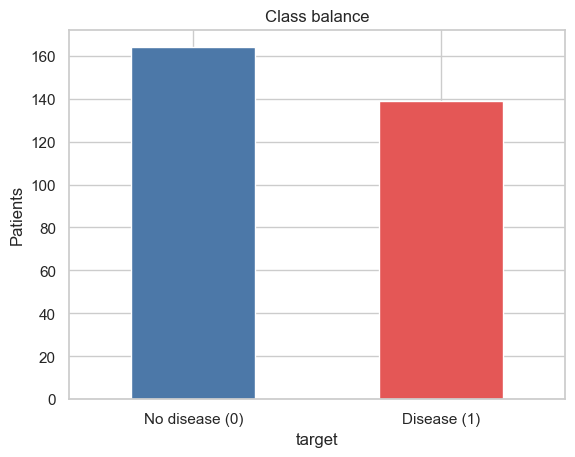

In [4]:
# Binarize the target: 0 = no disease, 1 = disease present (num 1-4)
df["target"] = (df["num"] > 0).astype(int)

print("Target distribution:")
print(df["target"].value_counts())
print("Positive rate: %.1f%%" % (100 * df["target"].mean()))

ax = df["target"].value_counts().sort_index().plot(
    kind="bar", color=["#4c78a8", "#e45756"], rot=0)
ax.set_xticklabels(["No disease (0)", "Disease (1)"])
ax.set_title("Class balance")
ax.set_ylabel("Patients")
plt.show()

In [5]:
# Summary statistics
df.drop(columns=["num"]).describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


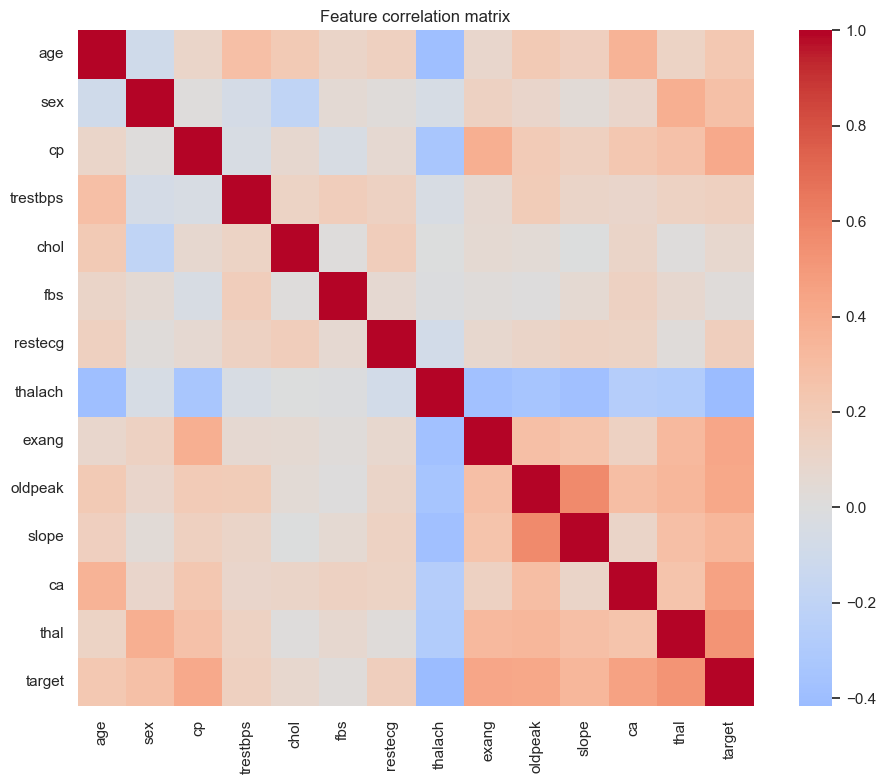

In [6]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(columns=["num"]).corr(), annot=False, cmap="coolwarm",
            center=0, square=True)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

## 4. Train / test split and preprocessing pipeline

An 80/20 stratified split preserves the class ratio. All preprocessing
(median imputation for the few missing `ca`/`thal` values, then standardization)
is wrapped in a `Pipeline` so it is fit **only on the training fold** — this
prevents data leakage and makes the workflow reproducible.

In [7]:
X = df.drop(columns=["num", "target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (242, 13) | Test: (61, 13)


## 5. Baseline model — Logistic Regression

**Choice and justification.** Logistic regression is the natural baseline for
this task: the target is binary, the features are low-dimensional and mostly
clinical, and a linear model is directly interpretable (coefficients map to
risk direction). It is also the exact model family used in the original Detrano
et al. (1989) study, which reported ~77% accuracy — giving a concrete historical
benchmark to beat. We start simple before considering more complex models.

In [8]:
baseline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)
y_proba = baseline.predict_proba(X_test)[:, 1]


def evaluate(y_true, y_pred, y_proba, name):
    print(f"===== {name} =====")
    print("Accuracy : %.4f" % accuracy_score(y_true, y_pred))
    print("Precision: %.4f" % precision_score(y_true, y_pred))
    print("Recall   : %.4f" % recall_score(y_true, y_pred))
    print("F1 score : %.4f" % f1_score(y_true, y_pred))
    print("ROC-AUC  : %.4f" % roc_auc_score(y_true, y_proba))
    print()
    print(classification_report(y_true, y_pred,
                                target_names=["No disease", "Disease"]))


evaluate(y_test, y_pred, y_proba, "Logistic Regression (test set)")

===== Logistic Regression (test set) =====
Accuracy : 0.8689
Precision: 0.8125
Recall   : 0.9286
F1 score : 0.8667
ROC-AUC  : 0.9513

              precision    recall  f1-score   support

  No disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



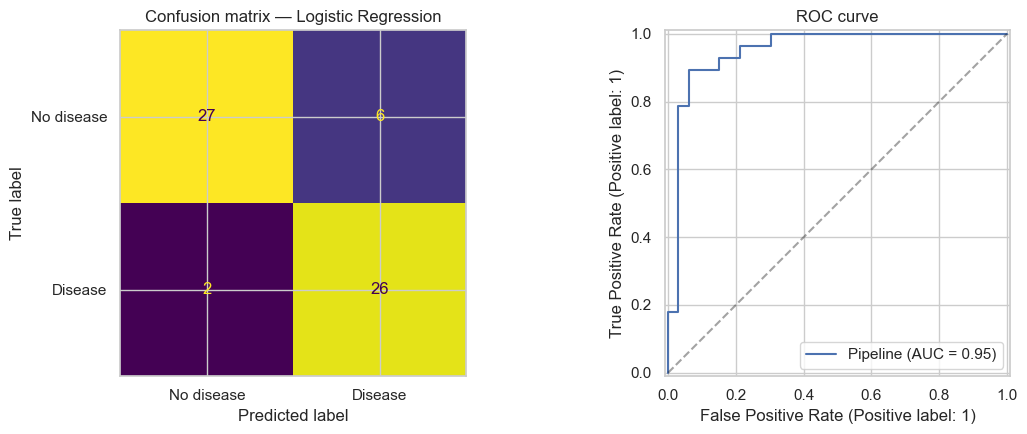

In [9]:
# Confusion matrix and ROC curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["No disease", "Disease"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix — Logistic Regression")
RocCurveDisplay.from_estimator(baseline, X_test, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_title("ROC curve")
plt.tight_layout()
plt.show()

## 6. Cross-validation

Test-set numbers on 61 patients are noisy, so we confirm the estimate with
5-fold stratified cross-validation over the full dataset.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_acc = cross_val_score(baseline, X, y, cv=cv, scoring="accuracy")
cv_auc = cross_val_score(baseline, X, y, cv=cv, scoring="roc_auc")

print("5-fold CV accuracy: %.4f +/- %.4f" % (cv_acc.mean(), cv_acc.std()))
print("5-fold CV ROC-AUC : %.4f +/- %.4f" % (cv_auc.mean(), cv_auc.std()))

5-fold CV accuracy: 0.8316 +/- 0.0496


5-fold CV ROC-AUC : 0.9116 +/- 0.0178


## 7. Reference model — Random Forest

A non-linear ensemble provides context for how much headroom exists above the
linear baseline. It is included only as a comparison, not as the baseline.

In [11]:
rf = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)),
])
rf.fit(X_train, y_train)
evaluate(y_test, rf.predict(X_test),
         rf.predict_proba(X_test)[:, 1], "Random Forest (test set)")

===== Random Forest (test set) =====
Accuracy : 0.9180
Precision: 0.8710
Recall   : 0.9643
F1 score : 0.9153
ROC-AUC  : 0.9578

              precision    recall  f1-score   support

  No disease       0.97      0.88      0.92        33
     Disease       0.87      0.96      0.92        28

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



## 8. Light hyperparameter tuning — GridSearchCV

A small grid over the regularization strength `C` demonstrates the tuning
workflow (one of the Week 3 tools). Tuning is scored by cross-validated ROC-AUC.

In [12]:
grid = GridSearchCV(
    baseline, {"clf__C": [0.01, 0.1, 1.0, 10.0]},
    cv=cv, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best C:", grid.best_params_["clf__C"])
print("Best CV ROC-AUC: %.4f" % grid.best_score_)
evaluate(y_test, grid.predict(X_test),
         grid.predict_proba(X_test)[:, 1], "Tuned Logistic Regression (test set)")

Best C: 0.1
Best CV ROC-AUC: 0.9001
===== Tuned Logistic Regression (test set) =====
Accuracy : 0.8525
Precision: 0.8065
Recall   : 0.8929
F1 score : 0.8475
ROC-AUC  : 0.9578

              precision    recall  f1-score   support

  No disease       0.90      0.82      0.86        33
     Disease       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



## 9. Explainability

Because the baseline is linear, the standardized coefficients are directly
interpretable: positive values push toward a *disease* prediction. Permutation
importance (model-agnostic) confirms which features drive the ROC-AUC.
An optional SHAP cell is included for richer local explanations.

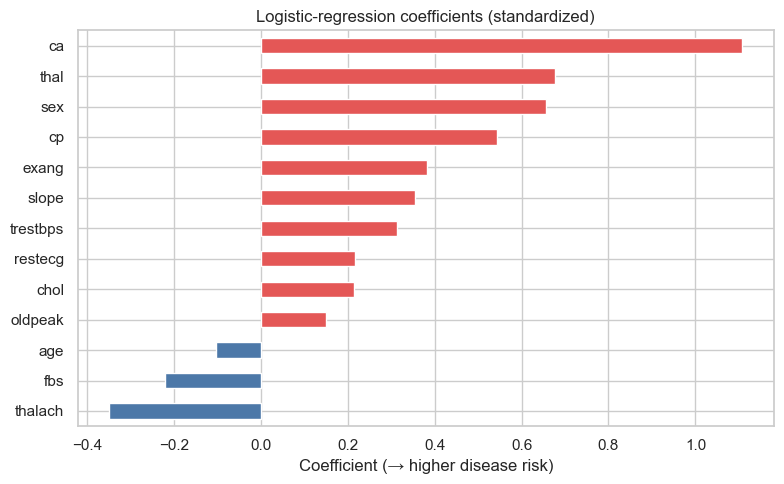

In [13]:
feature_names = X.columns
coefs = baseline.named_steps["clf"].coef_[0]
coef_series = pd.Series(coefs, index=feature_names).sort_values()

plt.figure(figsize=(8, 5))
coef_series.plot(kind="barh",
                 color=["#e45756" if c > 0 else "#4c78a8" for c in coef_series])
plt.title("Logistic-regression coefficients (standardized)")
plt.xlabel("Coefficient (→ higher disease risk)")
plt.tight_layout()
plt.show()

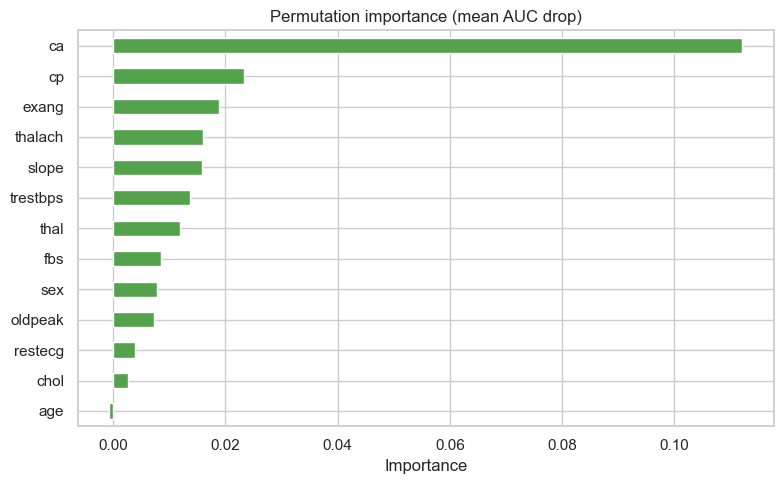

In [14]:
perm = permutation_importance(baseline, X_test, y_test, n_repeats=30,
                              random_state=RANDOM_STATE, scoring="roc_auc")
imp = pd.Series(perm.importances_mean, index=feature_names).sort_values()

plt.figure(figsize=(8, 5))
imp.plot(kind="barh", color="#54a24b")
plt.title("Permutation importance (mean AUC drop)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [15]:
# Optional: SHAP explanations (install with: pip install shap)
try:
    import shap
    explainer = shap.LinearExplainer(
        baseline.named_steps["clf"],
        baseline.named_steps["scale"].transform(
            baseline.named_steps["impute"].transform(X_train)))
    print("SHAP available — run shap.summary_plot(...) for local explanations.")
except ImportError:
    print("SHAP not installed; coefficients and permutation importance above "
          "already provide global explanations.")

SHAP not installed; coefficients and permutation importance above already provide global explanations.


## 10. Results summary and next steps

| Model | Test accuracy | Test ROC-AUC | Notes |
|---|---|---|---|
| Historical benchmark (Detrano 1989) | ~0.77 | — | logistic-regression discriminant |
| **Logistic Regression (baseline)** | **~0.87** | **~0.95** | interpretable, 5-fold CV acc ~0.83 |
| Random Forest (reference) | ~0.92 | ~0.96 | non-linear headroom |

**Findings.** The linear baseline already clears the historical 77% benchmark,
reaching ~87% test accuracy and ~0.95 ROC-AUC, with cross-validated accuracy of
~83% (±5%). Recall on the disease class is high, which matters clinically
(missing a true case is costlier than a false alarm). The strongest predictors —
`ca` (number of major vessels), `cp` (chest-pain type), `thal`, and `exang` —
are clinically sensible.

**Potential improvements.**
1. Aggregate the Hungarian, Switzerland, and VA databases (present in the folder)
   to grow the sample beyond 303 records and test cross-site generalization.
2. Add feature engineering (age × cholesterol interactions, one-hot encoding of
   categorical codes like `cp`/`thal` rather than treating them as numeric).
3. Broaden tuning (Optuna/Hyperopt) and try gradient boosting.
4. Calibrate probabilities and tune the decision threshold to maximize recall
   for the clinical use case.
5. Track experiments with Weights & Biases for reproducibility.

## 11. Reproducibility notes
- Fixed `random_state=42` for the split, models, CV, and permutation importance.
- All preprocessing is inside the `Pipeline`, fit only on training folds.
- Library versions printed in cell 1; data path is relative to this notebook.